# **Generating Isochrones for Pedestrian Counters in Melbourne**

**Outputs** (saved under `Output_data_from_isochrone_scripts`):

Graph Data

- `graphs_dict_15min.pkl`
- `graphs_dict_5min.pkl`

Sensor Data

- `sensor_locations_with_graphs.csv`

Visualization

- Isochrones and sensors on OpenStreetMap map

**Start Date:** *Oct 24, 2024*  
**Last Modification:** *Apr 2, 2025*  
**Authors:** *Kanaha Shoji & Benjamin Tarver*


In [1]:
# Import necessary libraries and functions
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import os
import pickle
import warnings
from datetime import datetime
import contextily as ctx
import matplotlib.patches as mpatches
import matplotlib.lines as mlines 
import matplotlib.ticker as mticker

In [2]:
# Set base directory to where data to be stored (**Modify the path as needed**)
base_dir = '/Users/shoji/Library/CloudStorage/OneDrive-epfl.ch/2025_03_Melbourne_walkability_study_final/Output_data_from_isochrone_scripts'
# Set base directory to where open data are stored
open_data_dir = '/Users/shoji/Library/CloudStorage/OneDrive-epfl.ch/2025_03_Melbourne_walkability_study_final/Open_datasets'

Pedestrian counter sensors location data downloaded from https://melbournetestbed.opendatasoft.com/explore/dataset/pedestrian-counting-system-sensor-locations/export/

In [3]:
# Read the sensor location csv file
sensor_locations = pd.read_csv(open_data_dir + '/pedestrian-counting-system-sensor-locations.csv')
original_sensor_locations = sensor_locations.copy()

In [4]:
sensor_locations['Location_Type'].unique()

array(['Outdoor', 'Indoor'], dtype=object)

In [5]:
# Remove the sensors that are installed after 2022 or located indoor
sensor_locations['Installation_Date'] = sensor_locations['Installation_Date'].fillna('2099-12-31')
sensor_locations['Installation_Date'] = sensor_locations['Installation_Date'].apply(lambda x: datetime.strptime(str(x).split()[0], '%Y-%m-%d'))
# Define the cutoff date
cutoff_date = datetime(2020, 1, 1)

# Filter the DataFrame
sensor_locations_filtered = sensor_locations[
    (sensor_locations['Location_Type'] == 'Outdoor') & 
    (sensor_locations['Installation_Date'] < cutoff_date)
].copy()

In [6]:
sensor_locations_filtered.drop(columns=['Direction_1','Direction_2','Status','Note'], inplace=True)
sensor_locations_filtered.dropna(subset =['Location_ID'],inplace=True)
sensor_locations_filtered.drop_duplicates(subset =['Location_ID'],inplace=True)
sensor_locations_filtered.head()

,Location_ID,Sensor_Description,Sensor_Name,Installation_Date,Location_Type,Latitude,Longitude,Location
0,2,Bourke Street Mall (South),Bou283_T,2009-03-30,Outdoor,-37.813807,144.965167,"-37.81380668, 144.96516718"
1,4,Town Hall (West),Swa123_T,2009-03-23,Outdoor,-37.814880,144.966088,"-37.81487988, 144.9660878"
2,6,Flinders Street Station Underpass,FliS_T,2009-03-25,Outdoor,-37.819117,144.965583,"-37.81911705, 144.96558255"
3,8,Webb Bridge,WebBN_T,2009-03-24,Outdoor,-37.822935,144.947175,"-37.82293543, 144.9471751"
4,10,Victoria Point,BouHbr_T,2009-04-23,Outdoor,-37.818765,144.947105,"-37.81876474, 144.94710545"


In [7]:
# Create a GeoDataFrame for the sensor locations
geometry = [Point(lon, lat) for lon, lat in zip(sensor_locations_filtered['Longitude'], sensor_locations_filtered['Latitude'])]
sensor_gdf = gpd.GeoDataFrame(sensor_locations_filtered, geometry=geometry)

In [8]:
lats, lons = zip(*[(p.y, p.x) for p in geometry])

north, south = max(lats), min(lats)
east, west = max(lons), min(lons)

In [9]:
print(north, south, east, west)

-37.79698741 -37.82401776 144.97323591 144.93970694


In [10]:
# Retrieve the street network data for the specified bounding box
G_walk = ox.graph_from_bbox(north+.02, south-.02, east+.02, west-.02, network_type='walk')
# impute missing edge speeds and calculate edge travel times with the speed module
G_walk = ox.speed.add_edge_speeds(G_walk)
G_walk = ox.speed.add_edge_travel_times(G_walk)

In [11]:
# Create a list to store the closest nodes
closest_nodes = []
node_latitudes = []
node_longitudes = []

# Iterate through each row in the dataframe
for _, row in sensor_locations_filtered.iterrows():
    location_name = row['Sensor_Name']
    latitude = row['Latitude']
    longitude = row['Longitude']

    # Use OSMnx to find the nearest node from the OpenStreetMap network
    nearest_node = ox.distance.nearest_nodes(G_walk, longitude,latitude) 
    # Store the node
    closest_nodes.append(nearest_node)

    # Get latitude and longitude of the nearest node
    node_lat = G_walk.nodes[nearest_node]['y']
    node_lon = G_walk.nodes[nearest_node]['x']
    node_latitudes.append(node_lat)
    node_longitudes.append(node_lon)

# Add new columns to the dataframe
sensor_locations_filtered['Closest Node'] = closest_nodes
sensor_locations_filtered['Closest Node Latitude'] = node_latitudes
sensor_locations_filtered['Closest Node Longitude'] = node_longitudes

In [12]:
travel_speed = 4.5  # walking speed in km/hour

# Add an edge attribute for time in minutes required to traverse each edge
meters_per_minute = travel_speed * 1000 / 60  # km per hour to m per minute
for _, _, _, data in G_walk.edges(data=True, keys=True):
    data["time"] = data["length"] / meters_per_minute

#### Defining functions

In [13]:
def visualize_polygons(trip_time = 15):# in minutes
    # Make the isochrone polygons for the sensor nodes
    isochrone_polys = []
    names = []  # to store the names (Counter Locations)
    for _, row in sensor_locations_filtered.iterrows():
        sensor_node = row['Closest Node']
        name = row['Sensor_Name']  # Get the name (Counter Location) from the row
        subgraph = nx.ego_graph(G_walk, sensor_node, radius=trip_time, distance="time")
        node_points = [Point((data["x"], data["y"])) for node, data in subgraph.nodes(data=True)]
        bounding_poly = gpd.GeoSeries(node_points).union_all().convex_hull #unary_union.convex_hull 
        isochrone_polys.append(bounding_poly)
        names.append(name)

    # Create a GeoSeries with separate polygons for each sensor node
    geos = gpd.GeoSeries(isochrone_polys)
    geos = geos.set_crs("EPSG:4326")

    # Plot the network then add isochrones as colored polygon patches
    fig, ax = ox.plot_graph(
        G_walk,show=False, close=False, edge_linewidth=0.2,node_size=0,bgcolor='none'
    )
    geos.plot(ax=ax, color='skyblue', ec="none", alpha=0.3, zorder=-1)
    plt.show()
    return geos

In [14]:
def create_graphs_dict(geos, pickle_file_name = 'graphs_dict_15min.pkl'):# geos = geos_15min
    gdf = gpd.GeoDataFrame(geometry=geos)
    gdf = gdf.rename(columns={0: 'geometry'})
    # Set 'geometry' as the active geometry column (optional but common for spatial operations)
    gdf = gdf.set_geometry('geometry')

    # Create an empty dictionary to store the graphs
    graphs_dict = {}

    # Iterate through the GeoDataFrame rows
    for idx, row in gdf.iterrows():
        # Get the ID and geometry for the current row
        poly_id = idx
        poly_geometry = row['geometry']

        # Temporarily suppress DeprecationWarnings for the current loop
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=DeprecationWarning)

            # Create the graph 'G' using osmnx.graph_from_polygon()
            G = ox.graph_from_polygon(poly_geometry)

        # Store the graph with its ID and geometry in the dictionary
        graphs_dict[f'G_{str(poly_id).zfill(3)}'] = {
            'ID': poly_id,
            'geometry': poly_geometry,
            'graph': G
        }

    # dump dict into pickle file since creating graphs_dict is a rather lengthy process
    with open(os.path.join(base_dir,f'{pickle_file_name}'), 'wb') as f:
        pickle.dump(graphs_dict, f)

### 15 min walk isochrones

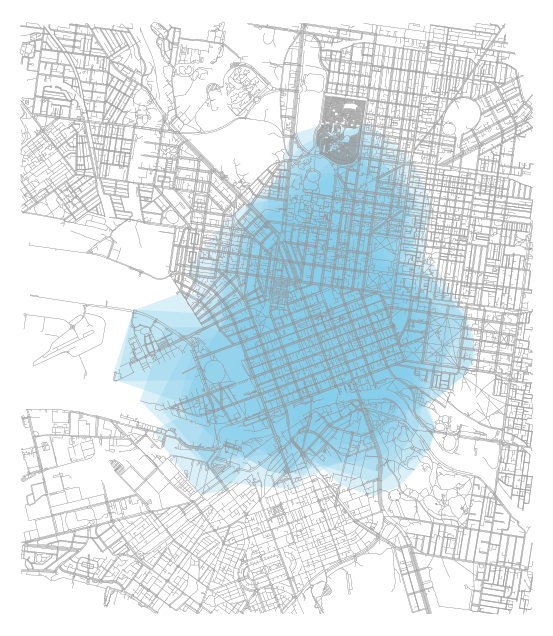

0     POLYGON ((144.97037 -37.82264, 144.9693 -37.82...
1     POLYGON ((144.97001 -37.82427, 144.96964 -37.8...
2     POLYGON ((144.96011 -37.82523, 144.95842 -37.8...
3     POLYGON ((144.94592 -37.83043, 144.94511 -37.8...
4     POLYGON ((144.94676 -37.8277, 144.93687 -37.81...
5     POLYGON ((144.93335 -37.81759, 144.93314 -37.8...
6     POLYGON ((144.96127 -37.8284, 144.95774 -37.82...
7     POLYGON ((144.97613 -37.82099, 144.96875 -37.8...
8     POLYGON ((144.96924 -37.82149, 144.969 -37.821...
9     POLYGON ((144.96749 -37.8189, 144.96663 -37.81...
10    POLYGON ((144.96944 -37.82108, 144.96877 -37.8...
11    POLYGON ((144.95826 -37.81558, 144.95463 -37.8...
12    POLYGON ((144.97021 -37.82906, 144.95977 -37.8...
13    POLYGON ((144.95952 -37.82764, 144.95824 -37.8...
14    POLYGON ((144.96734 -37.81093, 144.96716 -37.8...
15    POLYGON ((144.96894 -37.82124, 144.96255 -37.8...
16    POLYGON ((144.96206 -37.80782, 144.9616 -37.80...
17    POLYGON ((144.96192 -37.81742, 144.95512 -

In [15]:
geos_15min = visualize_polygons(trip_time=15)
print(geos_15min) 

In [16]:
create_graphs_dict(geos = geos_15min, pickle_file_name = 'graphs_dict_15min.pkl')

### 5 min walk isochrones

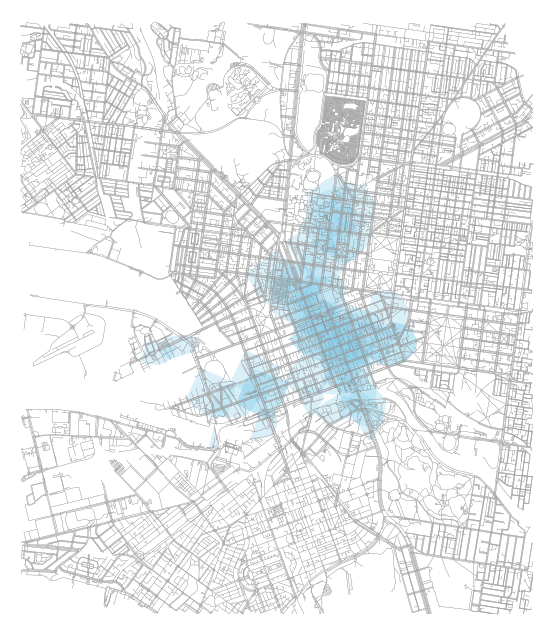

0     POLYGON ((144.96619 -37.81667, 144.96412 -37.8...
1     POLYGON ((144.96743 -37.81799, 144.96342 -37.8...
2     POLYGON ((144.96551 -37.81915, 144.96246 -37.8...
3     POLYGON ((144.94675 -37.82527, 144.94672 -37.8...
4     POLYGON ((144.94771 -37.82183, 144.94626 -37.8...
5     POLYGON ((144.93965 -37.81571, 144.938 -37.815...
6     POLYGON ((144.96137 -37.82169, 144.96126 -37.8...
7     POLYGON ((144.97252 -37.81589, 144.9724 -37.81...
8     POLYGON ((144.96665 -37.81539, 144.9665 -37.81...
9     POLYGON ((144.9691 -37.8146, 144.96752 -37.814...
10    POLYGON ((144.96935 -37.81583, 144.96637 -37.8...
11    POLYGON ((144.95559 -37.80916, 144.95476 -37.8...
12    POLYGON ((144.97035 -37.82305, 144.96818 -37.8...
13    POLYGON ((144.96445 -37.82265, 144.9642 -37.82...
14    POLYGON ((144.96637 -37.80439, 144.96511 -37.8...
15    POLYGON ((144.9695 -37.81602, 144.96596 -37.81...
16    POLYGON ((144.96359 -37.80177, 144.96111 -37.7...
17    POLYGON ((144.95903 -37.81113, 144.95876 -

In [17]:
geos_5min = visualize_polygons(trip_time=5)
print(geos_5min) 

In [18]:
create_graphs_dict(geos = geos_5min, pickle_file_name = 'graphs_dict_5min.pkl')

### Sensor Location (Location_ID) and graphs (Graph_ID) Mapping for merging later

In [19]:
# Create a mapping between the original GeoDataFrame index and the graph keys
graph_keys = [f'G_{str(idx).zfill(3)}' for idx in geos_5min.index]
sensor_locations_filtered['Graph_ID'] = graph_keys

# Save the updated file if needed
sensor_locations_filtered.to_csv(os.path.join(base_dir,'sensor_locations_with_graphs.csv'), index=False)

# Check the result
print(sensor_locations_filtered[['Location_ID', 'Graph_ID']].head())

   Location_ID Graph_ID
0            2    G_000
1            4    G_001
2            6    G_002
3            8    G_003
4           10    G_004


### Isochrone visualization

In [20]:
with open(os.path.join(base_dir,'graphs_dict_15min.pkl'), 'rb') as f:
    graphs_dict_15 = pickle.load(f)

with open(os.path.join(base_dir,'graphs_dict_5min.pkl'), 'rb') as f:
    graphs_dict_5 = pickle.load(f)

In [ ]:
def plot_multiple_polygons_with_sensors(graphs_dict_15, graphs_dict_5, sensor_locations_filtered, poly_ids):
    fig, ax = plt.subplots(figsize=(6, 6))

    all_sensors = []  # Store sensor locations to plot them once

    for poly_id in poly_ids:
        # Get graph keys
        graph_key_15 = f'G_{str(poly_id).zfill(3)}'
        graph_key_5 = f'G_{str(poly_id).zfill(3)}'

        # Retrieve the polygon geometries
        poly_data_15 = graphs_dict_15.get(graph_key_15)
        poly_data_5 = graphs_dict_5.get(graph_key_5)

        if not poly_data_15 or not poly_data_5:
            print(f"Polygon with ID {poly_id} not found in one or both datasets. Skipping.")
            continue

        poly_geometry_15 = poly_data_15['geometry']
        poly_geometry_5 = poly_data_5['geometry']

        # Filter corresponding sensors
        sensor_data_15 = sensor_locations_filtered[sensor_locations_filtered['Graph_ID'] == graph_key_15]
        sensor_data_5 = sensor_locations_filtered[sensor_locations_filtered['Graph_ID'] == graph_key_5]

        all_sensors.append(sensor_data_15)
        all_sensors.append(sensor_data_5)

        # Create GeoDataFrames for polygons
        poly_gdf_15 = gpd.GeoDataFrame(geometry=[poly_geometry_15], crs="EPSG:4326")
        poly_gdf_5 = gpd.GeoDataFrame(geometry=[poly_geometry_5], crs="EPSG:4326")

        # Plot polygons without legend to avoid duplicates
        poly_gdf_15.plot(ax=ax, color='lightblue', alpha=0.3, edgecolor='blue', label="_nolegend_")
        poly_gdf_5.plot(ax=ax, color='royalblue', alpha=0.3, edgecolor='blue', label="_nolegend_") # darkblue

    # Merge all sensor data and plot once
    if all_sensors:
        sensor_data_all = pd.concat(all_sensors).drop_duplicates()
        sensor_gdf_all = gpd.GeoDataFrame(sensor_data_all, 
                                          geometry=gpd.points_from_xy(sensor_data_all.Longitude, sensor_data_all.Latitude),
                                          crs="EPSG:4326")
        sensor_gdf_all.plot(ax=ax, color='blue', markersize=30, marker='o', label="_nolegend_")

    # Add basemap
    # ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs="EPSG:4326")
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, crs="EPSG:4326")

    # Manually create legend entries
    legend_patches = [
        mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=8, label='Sensor Locations'),  # Fix here
        mpatches.Patch(color='royalblue', alpha = 0.5,label='5-min walk isochrone'),
        mpatches.Patch(color='lightblue',alpha = 0.5,label='15-min walk isochrone')
    ]
    ax.legend(handles=legend_patches, loc="upper left", fontsize=9.4)

    # Remove the frame (spines) of the plot
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Reduce number of ticks and let Matplotlib pick "nice" values
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5, prune='both')) 
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.get_major_formatter().set_scientific(False)
    ax.yaxis.get_major_formatter().set_scientific(False)
    ax.xaxis.get_major_formatter().set_useOffset(False)
    ax.yaxis.get_major_formatter().set_useOffset(False)
    # Customize the plot
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    # ax.set_title(f"Polygons and Sensor Locations for IDs: {poly_ids}")
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, f"fig_03_isochrones.png"), dpi=1000)
    plt.show()


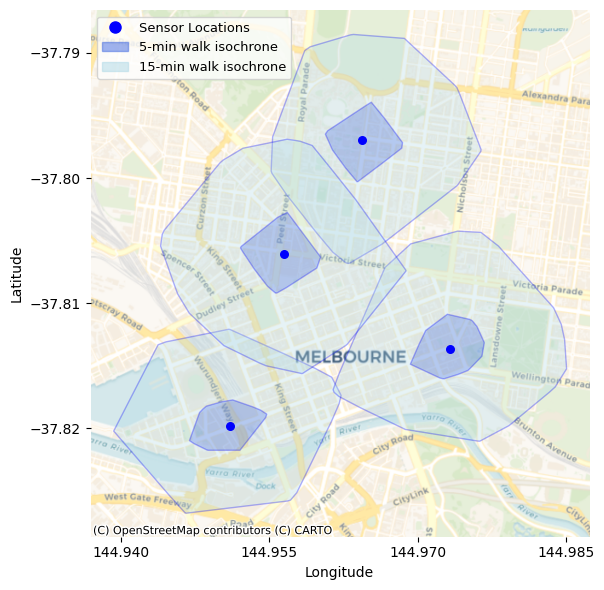

In [36]:
plot_multiple_polygons_with_sensors(graphs_dict_15, graphs_dict_5, sensor_locations_filtered, poly_ids=[36, 38, 26, 11])